Course link: https://www.youtube.com/watch?v=a4HBKEda_F8

# 1. Introdcution
The course is structured in two parts: 
1. Essential Elasticsearch fundamentals: index management, document storage, text analysis, pipeline creation, search functionality, and advanced features like semantic search and embeddings.

2. A practical section where you'll build a real-world website using Elasticsearch as a search engine, working with the Astronomy Picture of the Day (APOD) dataset to implement features such as data cleaning pipelines, tokenization, pagination, and aggregations.


# 2. Installation

1. Make sure docker is installed: https://www.docker.com/
2. Go to the following site and copy the command onto cmd: https://www.elastic.co/search-labs/tutorials/install-elasticsearch/docker


* Linux:\
  docker run -p 127.0.0.1:9200:9200 -d --name elasticsearch \
    -e "discovery.type=single-node" \
    -e "xpack.security.enabled=false" \
    -e "xpack.license.self_generated.type=trial" \
    -v "elasticsearch-data:/usr/share/elasticsearch/data" \
    docker.elastic.co/elasticsearch/elasticsearch:8.15.0


* Windows:\
  docker run -p 127.0.0.1:9200:9200 -d --name elasticsearch -e "discovery.type=single-node" -e "xpack.security.enabled=false" -e "xpack.license self_generated.type=trial" -v "elasticsearch-data:/usr/share/elasticsearch/data" docker.elastic.co/elasticsearch/elasticsearch:8.15.0




check your container is up and running in http://localhost:9200.

* To stop and remove it, run this in cmd: 
  
  **docker stop elasticsearch**
   
  **docker rm elasticsearch**
* To stop it but keep it (so you can restart it later): **docker stop elasticsearch**
  Then restart it with: **docker start elasticsearch**
* Check status anytime with: **docker ps -a**
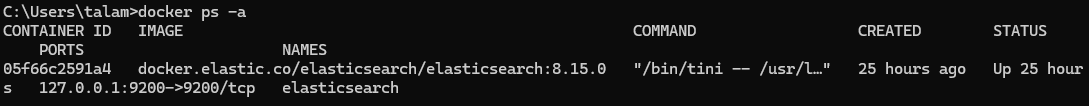

In [1]:
# run this cell to install the necessary dependencies
%pip install "elasticsearch<9"

Note: you may need to restart the kernel to use updated packages.


## Imports

In [2]:
# all imports of the notebook
from elasticsearch import Elasticsearch
from elasticsearch import helpers
from pprint import pprint
import base64

# 3. Create an Index

## Definitions:
* **Index**: collection of documents that share similar characteristics.
    Can be compared to datasbase in a relational database (i.e. SQL) and optimized for searching large volumes of textual, numeric and structured data.
* **Shard**: a partition of an index. The index is divided into multiple shards, and each shard stores a subset of the documents. This allows data to be distributed across nodes and queries to be executed in parallel.
    Elasticsearch knows how to reconstruct the documents to find the information we need.

* **Replica**: a copy of the data (i.e., replica=1 means each shard is duplicated once). Each replica shard has the same data and structure as its primary shard. Replicas are used for system resilience (fault tolerance) and for improving search performance by allowing parallel searches.

In [3]:
# Connect to Elasticsearch
es = Elasticsearch("http://localhost:9200")

# Check if the connection is successful
if es.ping():
    print("Connected to Elasticsearch!")

    # Get and print cluster information
    info = es.info()
    pprint(info)
else:
    print("Connection failed.")

Connected to Elasticsearch!
ObjectApiResponse({'name': '8ad92a9e339e', 'cluster_name': 'docker-cluster', 'cluster_uuid': 'Yn5zjAt7TUOntAMcWpLSeg', 'version': {'number': '8.15.0', 'build_flavor': 'default', 'build_type': 'docker', 'build_hash': '1a77947f34deddb41af25e6f0ddb8e830159c179', 'build_date': '2024-08-05T10:05:34.233336849Z', 'build_snapshot': False, 'lucene_version': '9.11.1', 'minimum_wire_compatibility_version': '7.17.0', 'minimum_index_compatibility_version': '7.0.0'}, 'tagline': 'You Know, for Search'})


In [4]:
# Helper functions for the whole notebook

def create_dummy_index(index_name):
    # dummy index and documents for the next section
    if es.indices.exists(index=index_name):
        es.indices.delete(index=index_name)
        print(f"Index '{index_name}' deleted.")


    es.indices.create(index=index_name, mappings={
        "properties": {
            "field1": {"type": "text"},
            "field2": {"type": "keyword"}
        }
    })

    # creating 3 dummy docs
    docs = [
        {"field1": "This is the first document.", "field2": "A"},
        {"field1": "This is the second document.", "field2": "B"},
        {"field1": "This is the third document.", "field2": "C"}
    ]

    # adding the dummy docs to the index
    for doc in docs:
        response = es.index(index=index_name, body=doc)
        print(f"Document indexed with ID: {response['_id']} and result: {response['result']}")


In [5]:
# deleting the index if it already exists
if es.indices.exists(index="my_index"):
    es.indices.delete(index="my_index")
    print("Index 'my_index' deleted.")

# creating an index
index_name = "my_index"
if not es.indices.exists(index=index_name):
    # create the index + change settings: shards and replicas
    es.indices.create(index=index_name, body={"settings": {"number_of_shards": 3, "number_of_replicas": 2}})

    # print the response + check index settings
    response = es.indices.get(index=index_name)
    pprint(response)
else:    
    print(f"Index '{index_name}' already exists.")
    

Index 'my_index' deleted.
ObjectApiResponse({'my_index': {'aliases': {}, 'mappings': {}, 'settings': {'index': {'routing': {'allocation': {'include': {'_tier_preference': 'data_content'}}}, 'number_of_shards': '3', 'provided_name': 'my_index', 'creation_date': '1773596982049', 'number_of_replicas': '2', 'uuid': 'GrO52CryTLmJe9tR4XwySQ', 'version': {'created': '8512000'}}}}})


# 4. Inserting Documents

## Definitions:
* **Mapping**: the process elasticsearch does in order to automatically detect the types of the fields in the document.

**Note**: manual mappping should be done in the creation of the index and before inserting any documents.
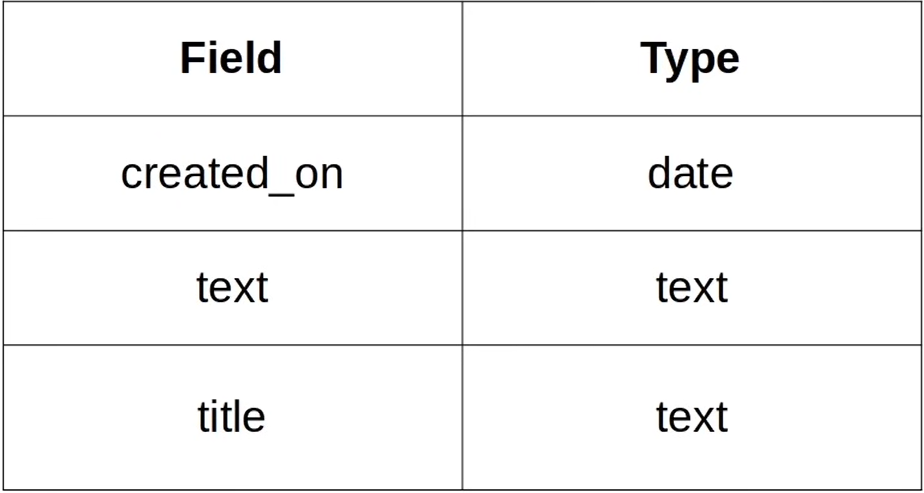

**Note**: all documents have to be in a JSON format and with the same fields in order to add them to the index.

### adding an example document to the index

In [6]:

doc = {
    'title': 'Elasticsearch Basics',
    'text': 'This is a basic introduction to Elasticsearch.',
    'created_on': '2024-06-01'
}

response = es.index(index=index_name, body=doc)
print("Document indexed:", response['result'])

Document indexed: created


In [7]:
# printing other information about the indexed document
print("Document ID:", response['_id'])
print("Index:", response['_index'])
print("Shards:", response['_shards'])

Document ID: R3ae8pwBNm0V73y7Sbh-
Index: my_index
Shards: {'total': 3, 'successful': 1, 'failed': 0}


### Insertinng multiple documents

In [8]:

docs = [
    {'title': 'Elasticsearch Advanced', 'text': 'This is an advanced guide to Elasticsearch.', 'created_on': '2024-06-02'},
    {'title': 'Elasticsearch Querying', 'text': 'Learn how to query Elasticsearch effectively.', 'created_on': '2024-06-03'},
    {'title': 'Elasticsearch Scaling', 'text': 'Best practices for scaling Elasticsearch clusters.', 'created_on': '2024-06-04'}
]

# define functions
def insert_document(document):
    response = es.index(index=index_name, body=document)
    return response

def print_info(response):
    print(f"""Document ID: {response['_id']} is {response['result']} in index: {response['_index']} and is split into {response['_shards']['total']} shards.""")
    

# insert documents and print info
for doc in docs:
    response = insert_document(doc)
    print_info(response)


Document ID: SHae8pwBNm0V73y7S7jt is created in index: my_index and is split into 3 shards.
Document ID: SXae8pwBNm0V73y7TLgN is created in index: my_index and is split into 3 shards.
Document ID: Snae8pwBNm0V73y7TLg9 is created in index: my_index and is split into 3 shards.


In [9]:
# Showing the elasticsearch mapping
mapping = es.indices.get_mapping(index=index_name)
pprint(mapping[index_name]['mappings']['properties'])

{'created_on': {'type': 'date'},
 'text': {'fields': {'keyword': {'ignore_above': 256, 'type': 'keyword'}},
          'type': 'text'},
 'title': {'fields': {'keyword': {'ignore_above': 256, 'type': 'keyword'}},
           'type': 'text'}}


### Manual mapping

In [10]:
mapping = {
    "properties": {
        "title": {"type": "text",
            'fields': {
                'keyword': {
                    'type': 'keyword',
                    'ignore_above': 256
                    }
            }},
        "text": {"type": "text",
                 'fields': {
                     'keyword': {
                            'type': 'keyword',
                            'ignore_above': 256
                         }
                 }},
        "created_on": {"type": "date"}
    }
}

es.indices.put_mapping(index=index_name, body=mapping)
mapping = es.indices.get_mapping(index=index_name)
pprint(mapping[index_name]['mappings']['properties'])

{'created_on': {'type': 'date'},
 'text': {'fields': {'keyword': {'ignore_above': 256, 'type': 'keyword'}},
          'type': 'text'},
 'title': {'fields': {'keyword': {'ignore_above': 256, 'type': 'keyword'}},
           'type': 'text'}}


## 5. Field Data Types

#### Common Data Types:
* **Binary**: accepts binary values as Base64 encoded string. Not searchable and not stored (Base64 is expensive to store). To get the binary value, we use the '_source' key. (Ex. Images)
* **Boolean**: True/False.
* **Numbers**: long, integer, byte, short, etc.
* **Dates**.
* **Keyword**: IDs, email addresses, status codes, zip codes, etc.

#### Object Data Types (JSON Format):
* **Object**
**Note**: Indexation of object:
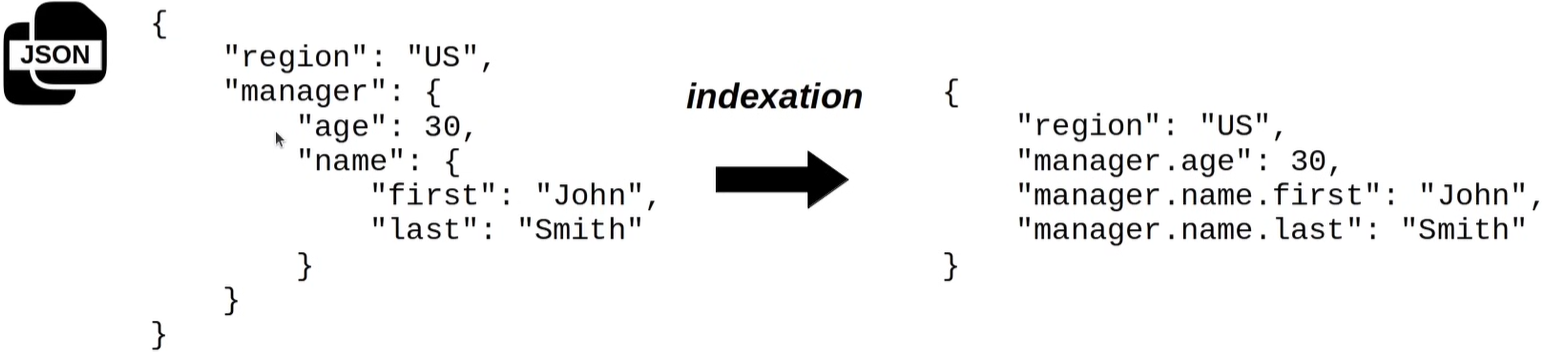

* **Flattened**: Efficient for deeply nested JSON objects. Hierarchical structure not preserved.

* **Nested**: used when we have an array of objects, maintains relationship between the object fields.

**Ex. Flattened**: note that the first name and last names aren't aligned anymore after indexation!
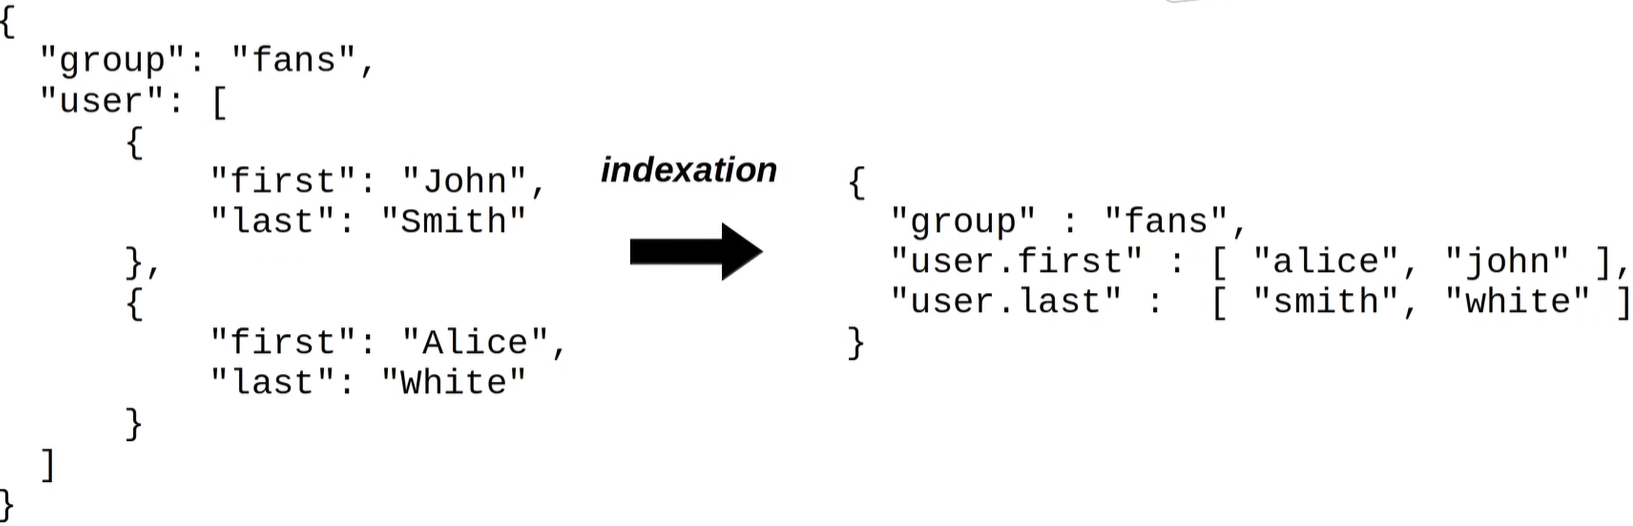

**Ex. Nested**: first and last name would be aligned.


#### Text Search Types:

* **Text**: full-text content. Elasticsearch will attempt to analyze the document in order to optimize the search.
* **Completion**.
* **Search as you type**.
* **Annotated text**.


#### Spatial Data Types:
* **Geo point**: storing the latitude and longtitude of a point.
* **Geo shape**: used to store complex shapes (stores a list of points - needs to be a closed shape so starting point is the same as ending point): 
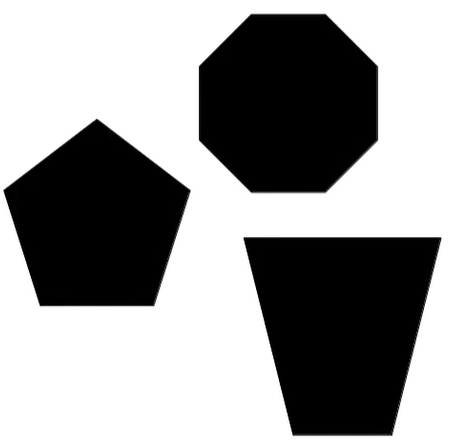
* **Point**: Cartesian point.
* **Shape**: Cartesian geometry.

### Example: Binary

In [11]:
# binary index
# check if already exists and if so, delete it
if es.indices.exists(index="binary_index"):
    es.indices.delete(index="binary_index")
    print("Index 'binary_index' deleted.")
es.indices.create(index="binary_index", body={
    "mappings": {
        "properties": {
            "data": {
                "type": "binary"
            }
        }
    }
})
print("Binary index 'binary_index' created.")

# prepare binary document - image
img_path = "Stray-Kids-Logo.png"
with open(img_path, "rb") as f:  
    img_data = f.read()
    # base 64 encode the binary data
    encoded_data = base64.b64encode(img_data).decode('utf-8')
    print("Binary data encoded to base64: ", encoded_data[:100], "...")  # print the first 100 characters of the encoded data


# Insert document into index
binary_doc = {
    "data": encoded_data
}
response = es.index(index="binary_index", body=binary_doc)
print("Binary document indexed:", response['result'])

Index 'binary_index' deleted.
Binary index 'binary_index' created.
Binary data encoded to base64:  iVBORw0KGgoAAAANSUhEUgAADwAAAAlgCAMAAAACwTJvAAAAS1BMVEVHcEwAAAAAAAAAAAAAAAAAAAAJAQI0BwwBAAAzBwwAAAAA ...
Binary document indexed: created


### Example: Object Type

In [12]:
# checking if object index exists, and if so, delete it
if es.indices.exists(index="object_index"):
    es.indices.delete(index="object_index")
    print("Index 'object_index' deleted.")

# creating an index
index_name = "object_index"
es.indices.create(index=index_name, mappings={
    "properties": {
        "author": {  # custom object field
            "properties": {
                "first name": {"type": "text"},
                "last name": {"type": "text"}
            }
        }
    }
}) 


# creating a document with an object field
object_doc = {
    "author": {
        "first name": "John",
        "last name": "Doe"
    }
}

# Insert object document into index
response = es.index(index=index_name, body=object_doc)
print("Object document indexed:", response['result'])

Index 'object_index' deleted.
Object document indexed: created


In [13]:
# print more properties
print(f"""Document ID: {response['_id']} is {response['result']} in index: {response['_index']} and is split into {response['_shards']['total']} shards.""")
print("Note: the 'author' object field allows us to query individual subfields like 'first name' or 'last name' directly, unlike the flattened field where all data is indexed as a single string.")

Document ID: THae8pwBNm0V73y7X7hV is created in index: object_index and is split into 2 shards.
Note: the 'author' object field allows us to query individual subfields like 'first name' or 'last name' directly, unlike the flattened field where all data is indexed as a single string.


### Example: Flattened Type

In [14]:
# checking if flattened index exists, and if so, delete it
if es.indices.exists(index="flattened_index"):
    es.indices.delete(index="flattened_index")
    print("Index 'flattened_index' deleted.")

# creating an index
index_name = "flattened_index"  
es.indices.create(index=index_name, mappings={
    "properties": {
        "author": {  # flattened field
            "type": "flattened"
        }
    }
})

# Creating a document with a flattened field
flattened_doc = {
    "author": {
        "first name": "Jane",
        "last name": "Smith"
    }
}

# Insert flattened document into index
response = es.index(index=index_name, body=flattened_doc)
print("Flattened document indexed:", response['result'])

Index 'flattened_index' deleted.
Flattened document indexed: created


In [15]:
# print more properties
print(f"""Document ID: {response['_id']} is {response['result']} in index: {response['_index']} and is split into {response['_shards']['total']} shards.""")
print("Note: The 'author' field is indexed as a single flattened field, so we cannot query individual subfields like 'first name' or 'last name' directly.")

Document ID: TXae8pwBNm0V73y7Zrge is created in index: flattened_index and is split into 2 shards.
Note: The 'author' field is indexed as a single flattened field, so we cannot query individual subfields like 'first name' or 'last name' directly.


### Example: Nested Type

In [16]:
# checking if nested index exists, and if so, delete it
if es.indices.exists(index="nested_index"):
    es.indices.delete(index="nested_index")
    print("Index 'nested_index' deleted.")

# creating an index
index_name = "nested_index"
es.indices.create(index=index_name, mappings={
    "properties": {
        "author": {  # nested field
            "type": "nested"
        }
    }
})

# Creating a document with a nested field (with an array of objects to demonstrate the nested structure)
nested_doc = {
    "author": [
        {
            "first name": "Jane",
            "last name": "Smith"
        },
        {
            "first name": "John",
            "last name": "Doe"
        }
    ]
}

# Insert nested document into index
response = es.index(index=index_name, body=nested_doc)
print("Nested document indexed:", response['result'])

Index 'nested_index' deleted.
Nested document indexed: created


In [17]:
# print more properties
print(f"""Document ID: {response['_id']} is {response['result']} in index: {response['_index']} and is split into {response['_shards']['total']} shards.""")
print("Note: the 'author' nested field allows us to query individual subfields like 'first name' or 'last name' directly, unlike the flattened field where all data is indexed as a single string.")

Document ID: Tnae8pwBNm0V73y7a7jz is created in index: nested_index and is split into 2 shards.
Note: the 'author' nested field allows us to query individual subfields like 'first name' or 'last name' directly, unlike the flattened field where all data is indexed as a single string.


### Example: Text Type

In [18]:
## check if text indice exists, and if so, delete it
if es.indices.exists(index="text_index"):
    es.indices.delete(index="text_index")
    print("Index 'text_index' deleted.")

# creating an index
index_name = "text_index"
es.indices.create(index=index_name, mappings={
    "properties": {
        "email_body": { 
            "type": "text"
        }
    }
})

# Creating a document with a text field
text_doc = {
    "email_body": "This is the body of the email."
}

# Insert text document into index
response = es.index(index=index_name, body=text_doc)
print("Text document indexed:", response['result'])

Index 'text_index' deleted.
Text document indexed: created


In [19]:
# print more properties 
print(f"""Document ID: {response['_id']} is {response['result']} in index: {response['_index']} and is split into {response['_shards']['total']} shards.""")
print("Note: The 'email_body' text field is analyzed and tokenized, allowing for full-text search capabilities")

Document ID: T3ae8pwBNm0V73y7c7i9 is created in index: text_index and is split into 2 shards.
Note: The 'email_body' text field is analyzed and tokenized, allowing for full-text search capabilities


### Example: Completion Type

In [20]:
## check if completion indice exists, and if so, delete it
if es.indices.exists(index="completion_index"):
    es.indices.delete(index="completion_index")
    print("Index 'completion_index' deleted.")

# creating an index
index_name = "completion_index"
es.indices.create(index=index_name, mappings={
    "properties": {
        "suggest": { 
            "type": "completion"
        }
    }
})

# Creating a document with a completion field
completion_doc1 = {
    "suggest": {
        "input": ["Mars", "Planet"]
    }
}

completion_doc2 = {
    "suggest": {
        "input": ["Andromeda", "Galaxy"]
    }
}

# Insert completion documents into index
response = es.index(index=index_name, body=completion_doc1)
print("Completion document indexed:", response['result'])

response = es.index(index=index_name, body=completion_doc2)
print("Completion document indexed:", response['result'])

Index 'completion_index' deleted.
Completion document indexed: created
Completion document indexed: created


In [21]:
# print more properties 
print(f"""Document ID: {response['_id']} is {response['result']} in index: {response['_index']} and is split into {response['_shards']['total']} shards.""")
print("Note: The 'suggest' completion field allows for efficient auto-complete and suggestion features, as it is optimized for prefix queries and can provide real-time suggestions based on the indexed input.")

# example of a search query for the completion field
suggest_query = {
    "suggest": {
        "my_suggest": {
            "prefix": "Mar",
            "completion": {
                "field": "suggest"
            }
        }
    }
}
response = es.search(index=index_name, body=suggest_query)
print(f"Completion suggestions for prefix 'Mar': {response['suggest']['my_suggest'][0]['options']}")

Document ID: UXae8pwBNm0V73y7fLiq is created in index: completion_index and is split into 2 shards.
Note: The 'suggest' completion field allows for efficient auto-complete and suggestion features, as it is optimized for prefix queries and can provide real-time suggestions based on the indexed input.
Completion suggestions for prefix 'Mar': []


### Example: Geo point Type

In [22]:
# check if geopoint index exists, and if so, delete it
if es.indices.exists(index="geopoint_index"):
    es.indices.delete(index="geopoint_index")
    print("Index 'geopoint_index' deleted.")

# creating an index
index_name = "geopoint_index"
es.indices.create(index=index_name, mappings={
    "properties": {
        "location": { 
            "type": "geo_point"
        }
    }
})

# Creating a document with a geo_point field
geo_doc = {
    "text": "Geopoint is an objet using GeoJSON format",
    "location": {
        "type": "Point",
        "coordinates": [
            -73.935242, # longitude
            40.730610   # latitude
            ]  
    }
}

# Insert geo document into index
response = es.index(index=index_name, body=geo_doc)
print("Geo document indexed:", response['result'])

Index 'geopoint_index' deleted.
Geo document indexed: created


In [23]:
#print more properties
print(f"""Document ID: {response['_id']} is {response['result']} in index: {response['_index']} and is split into {response['_shards']['total']} shards.""")
print("Note: The 'location' geo_point field allows for geospatial queries, such as finding documents within a certain distance from a point or within a bounding box, making it ideal for location-based applications.")

Document ID: Unae8pwBNm0V73y7jrir is created in index: geopoint_index and is split into 2 shards.
Note: The 'location' geo_point field allows for geospatial queries, such as finding documents within a certain distance from a point or within a bounding box, making it ideal for location-based applications.


## 6. Delete Documents

In [24]:
index_name = "delete_test_index"
create_dummy_index(index_name)
# force Elasticsearch to refresh the index (so we can immidiatly see the changes in the next search query)
es.indices.refresh(index=index_name)

# seeing how many docs we have in the index before deletion
count_response = es.count(index=index_name)
print(f"Total documents in index before deletion: {count_response['count']}")

# get document id of the first document
search_response = es.search(index=index_name, body={"query": {"match_all": {}}})
first_doc_id = search_response['hits']['hits'][0]['_id']


# deleting the first document
es.delete(index=index_name, id=first_doc_id)
print(f"Document with ID: {first_doc_id} deleted.")

# force Elasticsearch to refresh the index (so we can immidiatly see the changes in the next search query)
es.indices.refresh(index=index_name)

# showing there are now 2 docs instead of 3
count_response = es.count(index=index_name)
print(f"Total documents in index after deletion: {count_response['count']}")

Index 'delete_test_index' deleted.
Document indexed with ID: U3ae8pwBNm0V73y7nbj- and result: created
Document indexed with ID: VHae8pwBNm0V73y7nrgt and result: created
Document indexed with ID: VXae8pwBNm0V73y7nrhC and result: created
Total documents in index before deletion: 3
Document with ID: U3ae8pwBNm0V73y7nbj- deleted.
Total documents in index after deletion: 2


## 7. Get Documents

In [25]:
index_name = "get_query_test_index"
create_dummy_index(index_name)

# force Elasticsearch to refresh the index (so we can immidiatly see the changes in the next search query)
es.indices.refresh(index=index_name)

# get document id of the first document
search_response = es.search(index=index_name, body={"query": {"match_all": {}}})
first_doc_id = search_response['hits']['hits'][0]['_id']

# get the first document using its id
get_response = es.get(index=index_name, id=first_doc_id)
print(f"Document with ID: {first_doc_id} retrieved. Source: {get_response['_source']}")

Index 'get_query_test_index' deleted.
Document indexed with ID: Vnae8pwBNm0V73y7qbhl and result: created
Document indexed with ID: V3ae8pwBNm0V73y7qbih and result: created
Document indexed with ID: WHae8pwBNm0V73y7qbjM and result: created
Document with ID: Vnae8pwBNm0V73y7qbhl retrieved. Source: {'field1': 'This is the first document.', 'field2': 'A'}


## 8. Exists API

In [26]:
# creating a dummy index
index_name = "existence_test_index"
create_dummy_index(index_name)
# force Elasticsearch to refresh the index (so we can immidiatly see the changes in the next search query)
es.indices.refresh(index=index_name)

# get document id of the first document
first_doc_id = es.search(index=index_name, body={"query": {"match_all": {}}})['hits']['hits'][0]['_id']

# checking if a document exists in a certain index
es.exists(index=index_name, id=first_doc_id)

Index 'existence_test_index' deleted.
Document indexed with ID: WXae8pwBNm0V73y7ubhm and result: created
Document indexed with ID: Wnae8pwBNm0V73y7ubiS and result: created
Document indexed with ID: W3ae8pwBNm0V73y7ubiz and result: created


HeadApiResponse(True)

### 9. Update Document

In [27]:
index_name = "update_test_index"

create_dummy_index(index_name)

# refresh so docs are searchable
es.indices.refresh(index=index_name)

# show initial number of docs
print("Total documents before update:", es.count(index=index_name)["count"])

# get ID of the first document
first_doc_id = es.search(index=index_name, query={"match_all": {}})["hits"]["hits"][0]["_id"]

# update field2 from A -> Z
update_response = es.update(
    index=index_name,
    id=first_doc_id,
    doc={"field2": "Z"}
)

print(f"Document {first_doc_id} updated. Result: {update_response['result']}")

# create a document if it doesn't exist (upsert)
update_response = es.update(
    index=index_name,
    id="doc_with_D",
    doc={"field1": "New document", "field2": "D"},
    doc_as_upsert=True
)

print(f"Document 'doc_with_D' upserted. Result: {update_response['result']}")

# refresh so updates are visible
es.indices.refresh(index=index_name)

# show final documents
search_response = es.search(index=index_name, query={"match_all": {}})

print("Documents after update:")
for hit in search_response["hits"]["hits"]:
    print(hit["_source"])

Index 'update_test_index' deleted.
Document indexed with ID: XHae8pwBNm0V73y7x7hj and result: created
Document indexed with ID: XXae8pwBNm0V73y7x7iH and result: created
Document indexed with ID: Xnae8pwBNm0V73y7x7ij and result: created
Total documents before update: 3
Document XHae8pwBNm0V73y7x7hj updated. Result: updated
Document 'doc_with_D' upserted. Result: created
Documents after update:
{'field1': 'This is the second document.', 'field2': 'B'}
{'field1': 'This is the third document.', 'field2': 'C'}
{'field1': 'This is the first document.', 'field2': 'Z'}
{'field1': 'New document', 'field2': 'D'}


## 10. Bulk API

Bulk API allows multiple operations (index, update, or delete) to be sent in a single request.
This reduces the number of HTTP requests and improves performance when processing many documents.

In [28]:
# building dummy bulk index and documents for the next section
index_name = "bulk_index"
create_dummy_index(index_name)

# refresh so existing docs are searchable
es.indices.refresh(index=index_name)

# bulk operations list
actions = [
    {
        "_op_type": "index",
        "_index": index_name,
        "_source": {"field1": "Bulk document 1", "field2": "X"}
    },
    {
        "_op_type": "index",
        "_index": index_name,
        "_source": {"field1": "Bulk document 2", "field2": "Y"}
    },
    {
        "_op_type": "update",
        "_index": index_name,
        "_id": es.search(index=index_name, query={"match_all": {}})["hits"]["hits"][0]["_id"],
        "doc": {"field2": "Z"}
    }
]

# execute bulk request
helpers.bulk(es, actions)

print("Bulk operations executed.")

# refresh so we can immediately see the changes
es.indices.refresh(index=index_name)

# show all documents after bulk operations
search_response = es.search(index=index_name, query={"match_all": {}})

print("Documents after bulk operations:")
for hit in search_response["hits"]["hits"]:
    print(hit["_source"])

Index 'bulk_index' deleted.
Document indexed with ID: X3ae8pwBNm0V73y7z7gj and result: created
Document indexed with ID: YHae8pwBNm0V73y7z7gz and result: created
Document indexed with ID: YXae8pwBNm0V73y7z7hC and result: created
Bulk operations executed.
Documents after bulk operations:
{'field1': 'This is the second document.', 'field2': 'B'}
{'field1': 'This is the third document.', 'field2': 'C'}
{'field1': 'Bulk document 1', 'field2': 'X'}
{'field1': 'Bulk document 2', 'field2': 'Y'}
{'field1': 'This is the first document.', 'field2': 'Z'}


## 11. Search API

#### Query DSL
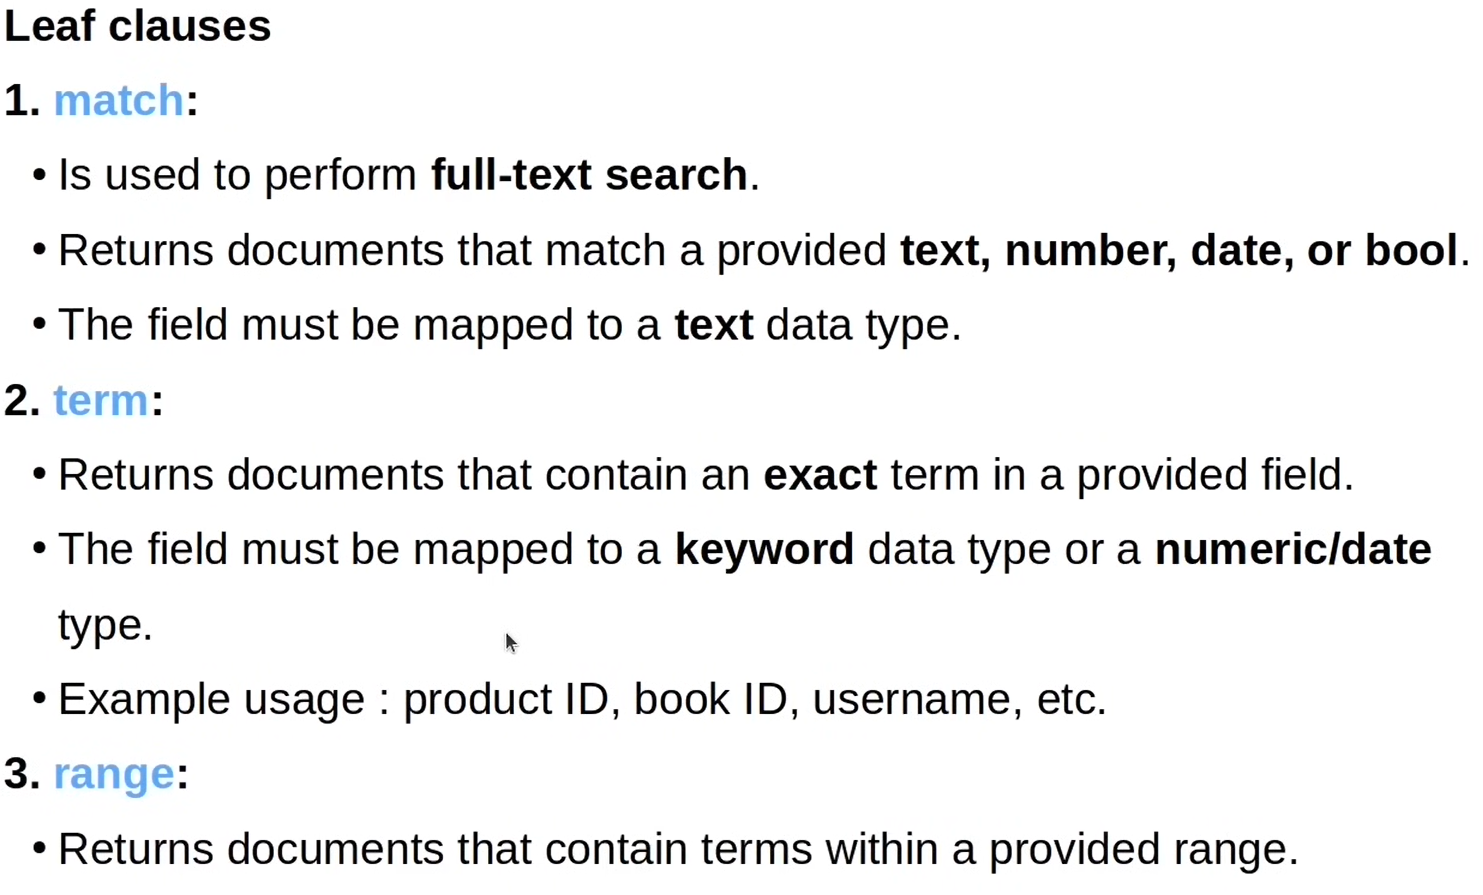
**Note**: to combine multiple leaf clauses we use:
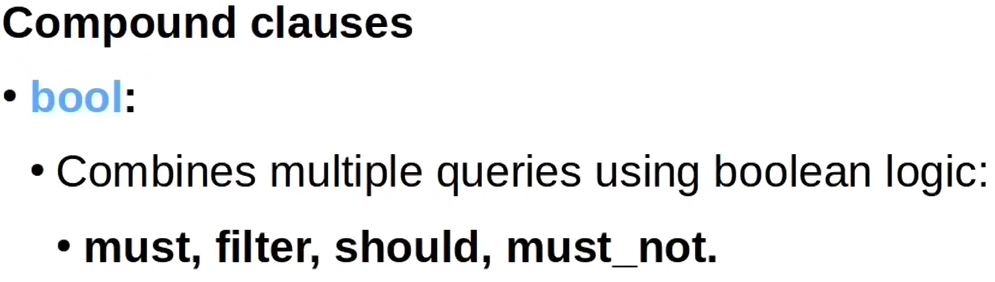

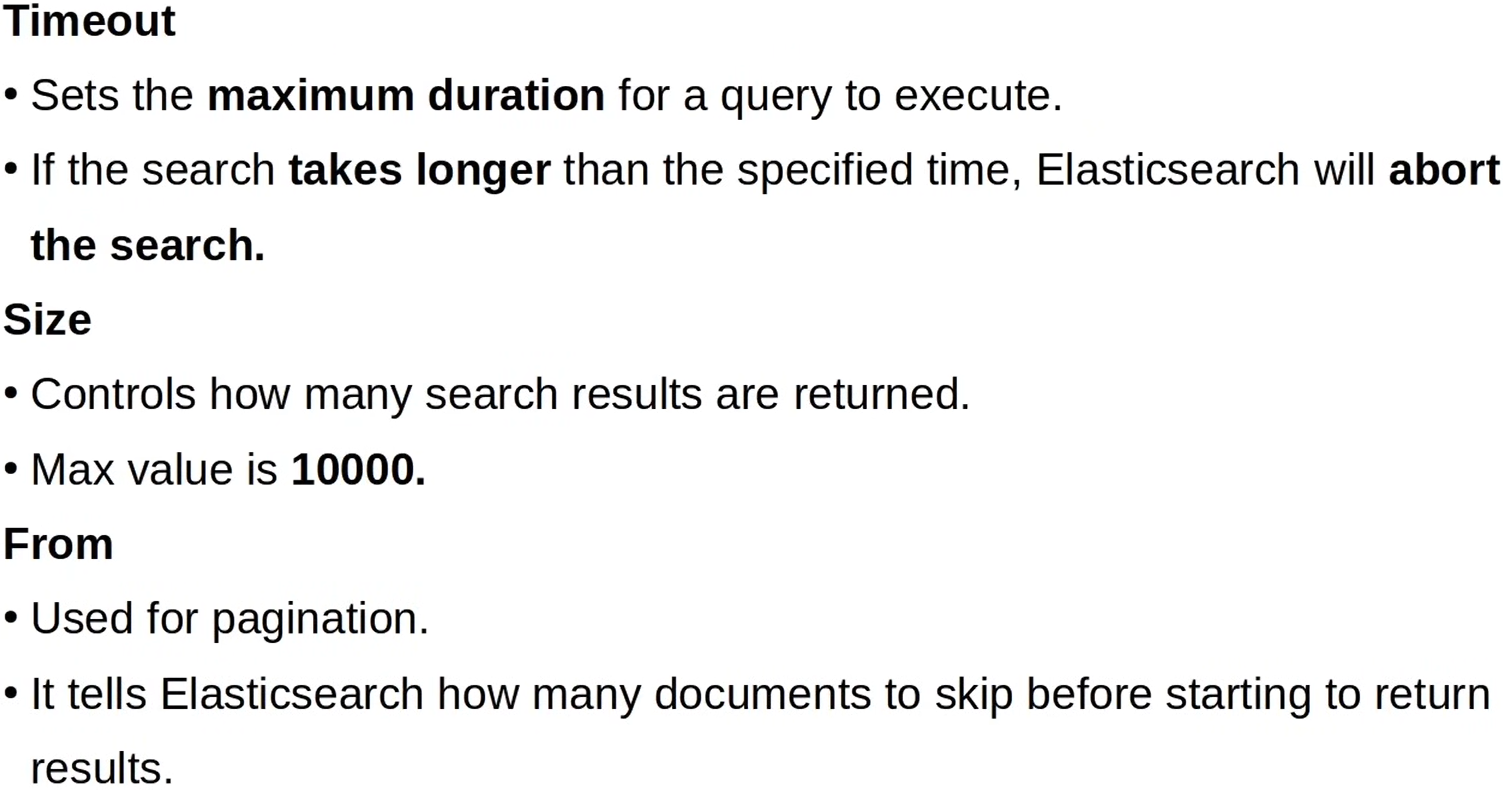
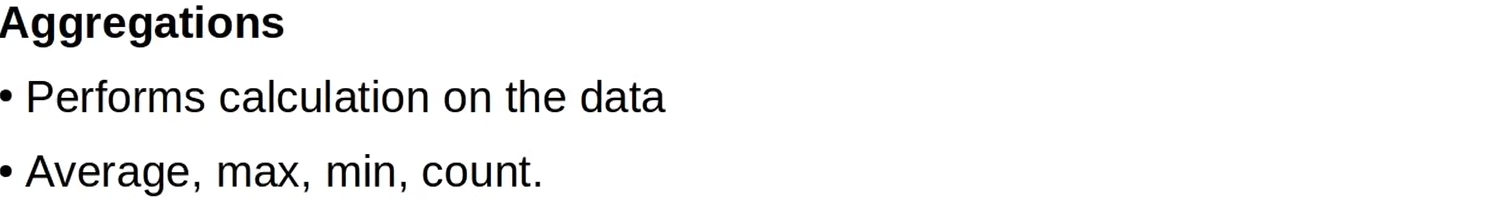

In [29]:
 # creating a dummy index for the next section
index_name = "search_test_index"
create_dummy_index(index_name)

# force Elasticsearch to refresh the index (so we can immidiatly see the changes in the next search query)
es.indices.refresh(index=index_name)

# search query to find all documents
search_query = {
    "query": {
        "match_all": {}
    }
}

# execute search query
search_response = es.search(index=index_name, body=search_query)

n_hits = search_response['hits']['total']['value']
print(f"Total hits: {n_hits}")

Index 'search_test_index' deleted.
Document indexed with ID: ZHae8pwBNm0V73y717gb and result: created
Document indexed with ID: ZXae8pwBNm0V73y717g3 and result: created
Document indexed with ID: Znae8pwBNm0V73y717hI and result: created
Total hits: 3


In [30]:
# create another index with a different name to show how we can search across multiple indices
index_name_2 = "search_test_index_2"
create_dummy_index(index_name_2)
# force Elasticsearch to refresh the index (so we can immidiatly see the changes in the next search query)
es.indices.refresh(index=index_name_2)

response = es.search(index=[index_name, index_name_2], body=search_query)

print(f"Total hits across both indices: {response['hits']['total']['value']}")


# search documents in all indices
search_response = es.search(index="*", body=search_query)
print(f"Total hits across all indices: {search_response['hits']['total']['value']}")

Index 'search_test_index_2' deleted.
Document indexed with ID: Z3ae8pwBNm0V73y74bhb and result: created
Document indexed with ID: aHae8pwBNm0V73y74bho and result: created
Document indexed with ID: aXae8pwBNm0V73y74bhy and result: created
Total hits across both indices: 6
Total hits across all indices: 10000


### Example: Leaf and Compound clauses

In [31]:
# leaf + compound query example
search_query = {
    "query": {
        "bool": {
            "must": [
                {"match": {"field1": "document"}}  # leaf clause
            ],
            "filter": [
                {"term": {"field2": "A"}}  # exact match filter
            ]
        }
    }
}

search_response = es.search(index=index_name, body=search_query)

print("Documents matching compound query:")
for hit in search_response["hits"]["hits"]:
    print(hit["_source"])

Documents matching compound query:
{'field1': 'This is the first document.', 'field2': 'A'}


#### Example: Pagination + Timeout

In [32]:
search_query = {
    "query": {
        "match_all": {}
    },
    "from": 0,
    "size": 2,
    "timeout": "2s"
}

search_response = es.search(index=index_name, body=search_query)

print("Paginated results:")
for hit in search_response["hits"]["hits"]:
    print(hit["_source"])

Paginated results:
{'field1': 'This is the first document.', 'field2': 'A'}
{'field1': 'This is the second document.', 'field2': 'B'}


#### Example: Aggregations

In [33]:
search_query = {
    "size": 0,  # we don't want to retrieve any documents, only aggregation results
    "aggs": {
        "field2_counts": {
            "terms": {
                "field": "field2"
            }
        }
    }
}

search_response = es.search(index=index_name, body=search_query)

print("Aggregation results:")
for bucket in search_response["aggregations"]["field2_counts"]["buckets"]:
    print(bucket["key"], bucket["doc_count"])

Aggregation results:
A 1
B 1
C 1


## 12. Dense Vector Field-Type, EMbeddings, KNN Search

* Stores dense vectors with numeric values.
* **Dense Vectors**: few or no zero elements in the vectors.
* Does not support aggregation or sorting.
* Does not support storing multiple values in one dense vector field (i.e [[],[]...]).
* Max size of a dense vector is 4096.
* Closest vectors are determined by KNN search.

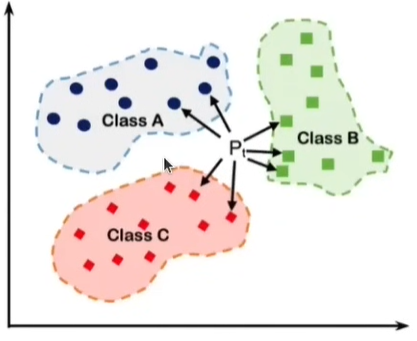


* **Note**: We have to manually do the mapping when using dense vectors as elasticsearch doesn't infer their mapping automatically. 


* **Embedding**: Converting text into a numerical vectors (can be done using deep learning models).
- input size is the size the model can process (commonly 256, 512 tokens). If text exceeds input ize, it will be truncated.
* **Note**: a good source for embedding models is the huggingface mteb: https://embeddings-benchmark.github.io/mteb/overview/available_models/text/

#### Embedding Preperation

In [34]:
%pip install sentence-transformers

Note: you may need to restart the kernel to use updated packages.


In [35]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

C:\Users\talam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3427.83it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [36]:
index_name = "vector_test_index"

if es.indices.exists(index=index_name):
    es.indices.delete(index=index_name)

es.indices.create(
    index=index_name,
    mappings={
        "properties": {
            "text": {"type": "text"},
            "embedding": {
                "type": "dense_vector",
                "dims": 384
            }
        }
    }
)

print("Index with dense vector mapping created.")

Index with dense vector mapping created.


In [37]:
# Create embeddings for documents
texts = [
    "Elasticsearch is a powerful search engine used for full text search and analytics.",
    "Machine learning models can convert text into vector embeddings for semantic search.",
    "Artificial intelligence helps computers understand natural language.",
    "Pizza with cheese and tomato sauce is a classic Italian dish.",
    "Pasta and pizza are popular foods in Italian cuisine.",
    "Deep learning models are commonly used to generate high-quality embeddings.",
    "Vector databases allow similarity search between documents.",
    "Neural networks are widely used in modern AI systems."
]

embeddings = model.encode(texts,show_progress_bar=True)

Batches: 100%|██████████| 1/1 [00:00<00:00,  2.31it/s]


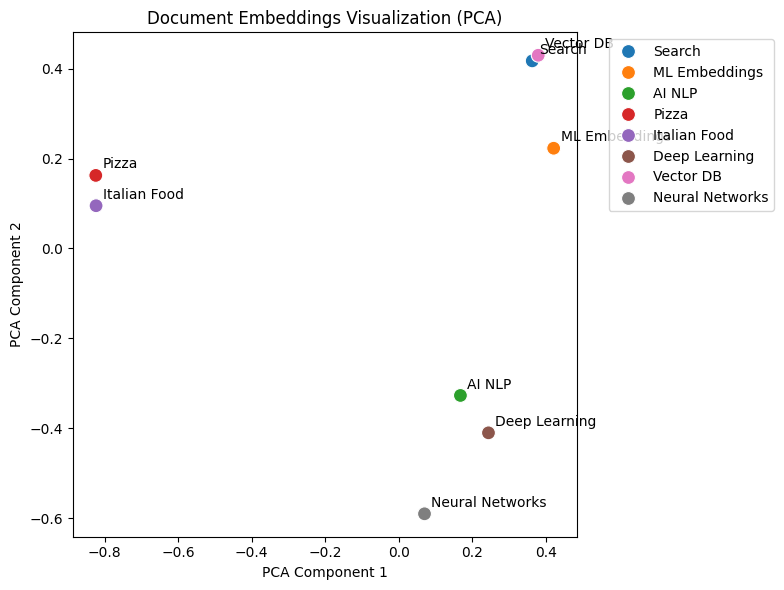

In [38]:
# visualize embeddings using PCA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

labels = [
    "Search",
    "ML Embeddings",
    "AI NLP",
    "Pizza",
    "Italian Food",
    "Deep Learning",
    "Vector DB",
    "Neural Networks"
]

# reduce embeddings from 384D → 2D
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# build dataframe for plotting
df = pd.DataFrame({
    "x": embeddings_2d[:, 0],
    "y": embeddings_2d[:, 1],
    "label": labels
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="x",
    y="y",
    hue="label",
    s=100
)

# add text labels next to points
for i in range(len(df)):
    plt.annotate(
        df["label"][i],
        (df["x"][i], df["y"][i]),
        xytext=(5,5),
        textcoords="offset points"
    )

plt.title("Document Embeddings Visualization (PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [39]:
# Index documents with embeddings (using Bulk API)
from elasticsearch import helpers

actions = []

for text, vector in zip(texts, embeddings):
    actions.append({
        "_index": index_name,
        "_source": {
            "text": text,
            "embedding": vector.tolist()
        }
    })

helpers.bulk(es, actions)

es.indices.refresh(index=index_name)

print("Documents with embeddings indexed using Bulk API.")

Documents with embeddings indexed using Bulk API.


#### Example: KNN Search

In [40]:
query_text = "AI models generate vector representations"
query_vector = model.encode(query_text).tolist()

response = es.search(
    index=index_name,
    knn={
        "field": "embedding",
        "query_vector": query_vector,
        "k": 2,
        "num_candidates": 10
    }
)

print("Closest documents:")
for hit in response["hits"]["hits"]:
    print(hit["_source"]["text"])

Closest documents:
Deep learning models are commonly used to generate high-quality embeddings.
Machine learning models can convert text into vector embeddings for semantic search.


## 13. Deep Pagination

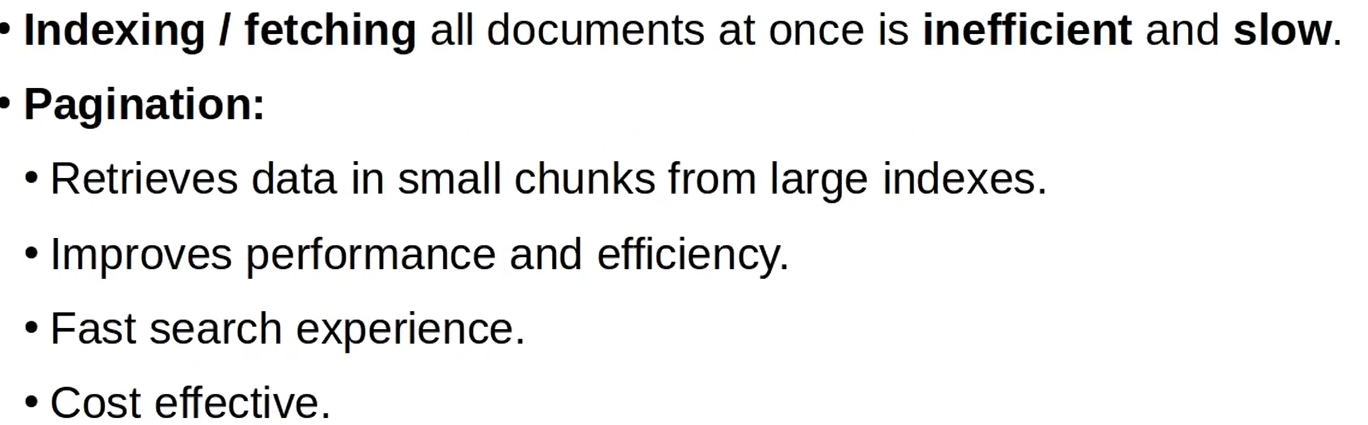
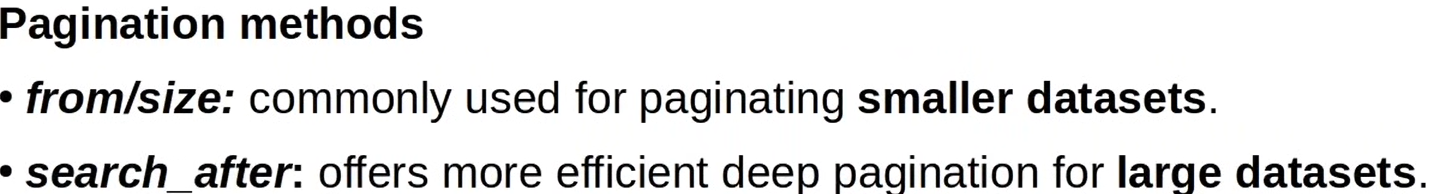

* **Note**: from/size is limited to 10k results as it requires a lot of memory for deep pages.

* **Note**: the search_after method isn't limited to 10k documents and doesn't utilize an offset (i.e like the from parameter). Results must be sorted (ID. timestamp, etc.) and the pointer of the last document according to the sorted values will tell us when to stop. +Doesn't need to skip documents (like with the from method), which makes it efficient for large documents.

In [41]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from elasticsearch import Elasticsearch, helpers

# ----------------------------
# Configuration
# ----------------------------
INDEX_NAME = "benchmark_index"
# DOC_COUNT = 20000
# PAGE_SIZE = 200
# ITERATIONS = 50  # number of pages to fetch per iteration

DOC_COUNT = 10000        # smaller index → less overhead
PAGE_SIZE = 200          # bigger page → fixed cost hidden
ITERATIONS = 50          # fewer iterations to focus on first pages

sort_field = "value"  # main field to sort

# ----------------------------
# Create index
# ----------------------------
if es.indices.exists(index=INDEX_NAME):
    es.indices.delete(index=INDEX_NAME)

es.indices.create(
    index=INDEX_NAME,
    body={
        "mappings": {
            "properties": {
                "value": {"type": "integer"},
                "doc_id": {"type": "integer"},
                "name": {"type": "keyword"}
            }
        }
    }
)

# ----------------------------
# Bulk insert documents
# ----------------------------
actions = [
    {
        "_index": INDEX_NAME,
        "_id": i,
        "_source": {
            "value": random.randint(0, 100000),
            "doc_id": i,        # unique numeric ID for search_after
            "name": f"doc_{i}"
        }
    }
    for i in range(DOC_COUNT)
]

helpers.bulk(es, actions)
es.indices.refresh(index=INDEX_NAME)  # ensure all docs are searchable

# ----------------------------
# Benchmarking
# ----------------------------
from_size_times = []
search_after_times = []

# ---------- from/size pagination using body ----------
num_pages = ITERATIONS
for iteration in range(ITERATIONS):
    iteration_times = []
    for page_num in range(num_pages):
        page_start = page_num * PAGE_SIZE
        body = {
            "from": page_start,        # start offset
            "size": PAGE_SIZE,         # page size
            "query": {"match_all": {}},
            "sort": [{"value": "asc"}, {"doc_id": "asc"}]
        }

        start = time.perf_counter()
        res = es.search(index=INDEX_NAME, body=body)
        elapsed_ms = (time.perf_counter() - start) * 1000
        iteration_times.append(elapsed_ms)

    from_size_times.append(iteration_times)



# ---------- search_after pagination using body ----------
num_pages = (DOC_COUNT + PAGE_SIZE - 1) // PAGE_SIZE  # total pages

for iteration in range(ITERATIONS):
    iteration_times = []
    last_sort_value = None

    for page_num in range(num_pages):
        body = {
            "query": {"match_all": {}},             # still need this
            "sort": [{"value": "asc"}, {"doc_id": "asc"}],
            "size": PAGE_SIZE
        }

        # continue from last page if available
        if last_sort_value is not None:
            body["search_after"] = last_sort_value

        start = time.perf_counter()
        res = es.search(index=INDEX_NAME, body=body)
        elapsed_ms = (time.perf_counter() - start) * 1000
        iteration_times.append(elapsed_ms)

        hits = res["hits"]["hits"]
        if hits:
            last_sort_value = hits[-1]["sort"]
        else:
            break  # no more docs

    search_after_times.append(iteration_times)

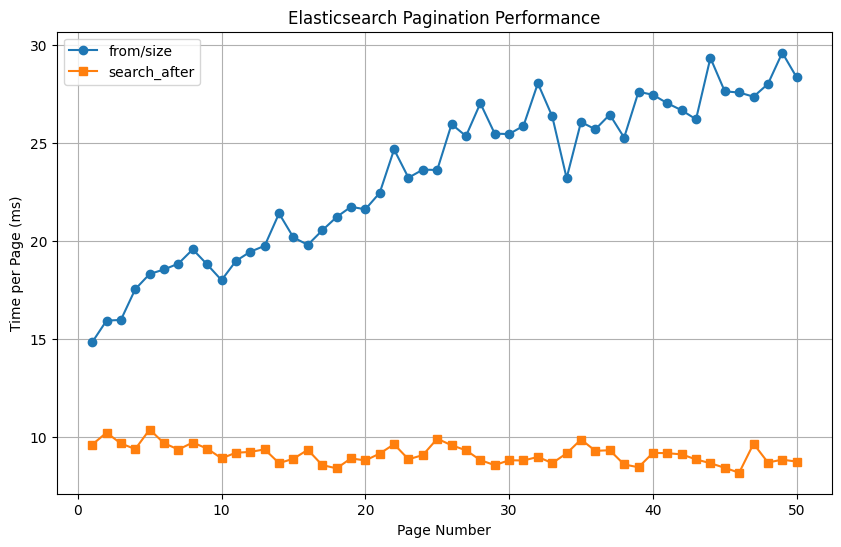

In [42]:
# ----------------------------
# Plot results
# ----------------------------
from_size_avg = np.mean(from_size_times, axis=0)
search_after_avg = np.mean(search_after_times, axis=0)
pages = np.arange(1, ITERATIONS+1)

plt.figure(figsize=(10,6))
plt.plot(pages, from_size_avg, label="from/size", marker="o")
plt.plot(pages, search_after_avg, label="search_after", marker="s")
plt.xlabel("Page Number")
plt.ylabel("Time per Page (ms)")
plt.title("Elasticsearch Pagination Performance")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
import numpy as np
import pandas as pd

# Convert to numpy arrays
from_size_array = np.array(from_size_times)       # shape: (ITERATIONS, num_pages)
search_after_array = np.array(search_after_times)

# Function to summarize
def summarize_method(times_array):
    # Flatten all pages for min/max/avg
    all_times = times_array.flatten()
    min_time = np.min(all_times)
    max_time = np.max(all_times)
    avg_time = np.mean(all_times)
    
    # Degradation = last page vs first page (average across iterations)
    first_pages = times_array[:, 0]
    last_pages = times_array[:, -1]
    perf_deg = np.mean((last_pages - first_pages) / first_pages * 100)
    
    return min_time, max_time, avg_time, perf_deg

# Summarize both methods
from_size_summary = summarize_method(from_size_array)
search_after_summary = summarize_method(search_after_array)

# Build a final summary table
summary_table = pd.DataFrame(
    [from_size_summary, search_after_summary],
    columns=["min (ms)", "max (ms)", "avg (ms)", "page_deg (%)"],
    index=["from/size", "search_after"]
)

print(summary_table)

              min (ms)  max (ms)   avg (ms)  page_deg (%)
from/size       6.2630  149.0412  23.353144     96.383172
search_after    4.7099   41.3609   9.104003      0.844999


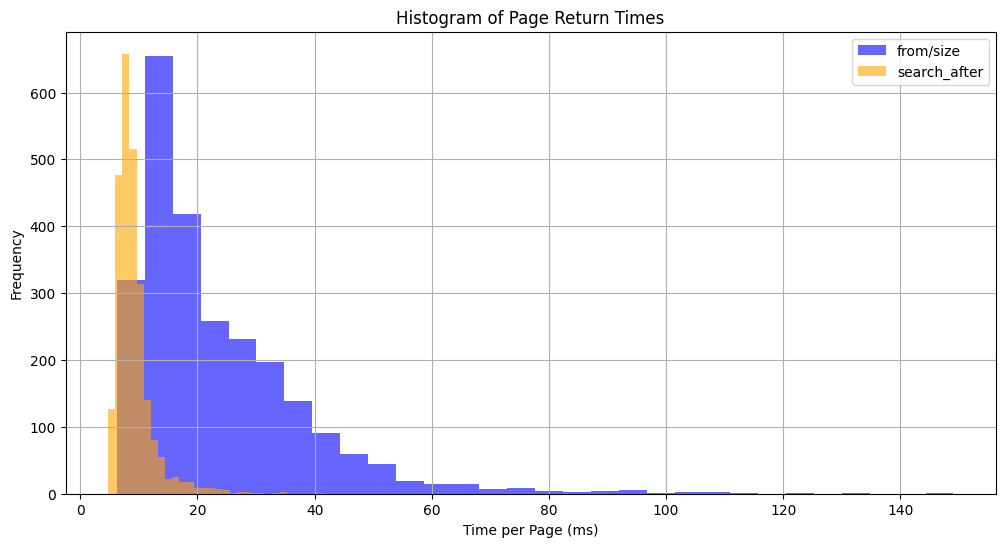

In [44]:
# ----------------------------
# Histogram of return times
# ----------------------------
import matplotlib.pyplot as plt

# Flatten the timing lists (all iterations x pages)
from_size_flat = [t for sublist in from_size_times for t in sublist]
search_after_flat = [t for sublist in search_after_times for t in sublist]

plt.figure(figsize=(12,6))

# From/size histogram
plt.hist(from_size_flat, bins=30, alpha=0.6, label='from/size', color='blue')

# Search_after histogram
plt.hist(search_after_flat, bins=30, alpha=0.6, label='search_after', color='orange')

plt.xlabel("Time per Page (ms)")
plt.ylabel("Frequency")
plt.title("Histogram of Page Return Times")
plt.legend()
plt.grid(True)
plt.show()

## 14. Ingest Pipelines

* Transformations before indexing.

In [49]:
index_name='pipeline_test'
# creating a dummy document for the next section
doc = {
    '_index':index_name,
    '_id':'1',
    '_source': {
        'text': 'HELLO_WORLD'
    }
}


# create pipeline
response = es.ingest.put_pipeline(
    id='lowercase_pipeline',
    description='This pipeline transforms text to lowercase',
    processors=[
        {
            'lowercase': {
                'field': 'text'
            }
        }
    ]
)

pprint(response.body)

{'acknowledged': True}


In [50]:
# get pipeline
response = es.ingest.get_pipeline(id='lowercase_pipeline')
pprint(response)

# Note: to delete we write es.ingest.delete_pipeline


# simulate the pipeline (add fake data to check if working right)
response = es.ingest.simulate(id='lowercase_pipeline',
                             docs=[doc]
                             )

pprint(response)

ObjectApiResponse({'lowercase_pipeline': {'description': 'This pipeline transforms text to lowercase', 'processors': [{'lowercase': {'field': 'text'}}]}})
ObjectApiResponse({'docs': [{'doc': {'_index': 'pipeline_test', '_version': '-3', '_id': '1', '_source': {'text': 'hello_world'}, '_ingest': {'timestamp': '2026-03-15T18:04:23.528763877Z'}}}]})


In [ ]:
es.indices.delete(index=index_name, ignore_unavailable=True)
es.indices.create(index=index_name)

# add document to index
response = es.index(
    index=index_name,
    id=doc["_id"],
    document=doc["_source"],
    pipeline="lowercase_pipeline"
)
pprint(response.body)

{'_id': '1',
 '_index': 'pipeline_test',
 '_primary_term': 1,
 '_seq_no': 0,
 '_shards': {'failed': 0, 'successful': 1, 'total': 2},
 '_version': 1,
 'result': 'created'}


In [53]:
res = es.get(index=index_name, id="1")
pprint(res.body)

{'_id': '1',
 '_index': 'pipeline_test',
 '_primary_term': 1,
 '_seq_no': 0,
 '_source': {'text': 'hello_world'},
 '_version': 1,
 'found': True}


## 15. Ingest Processors

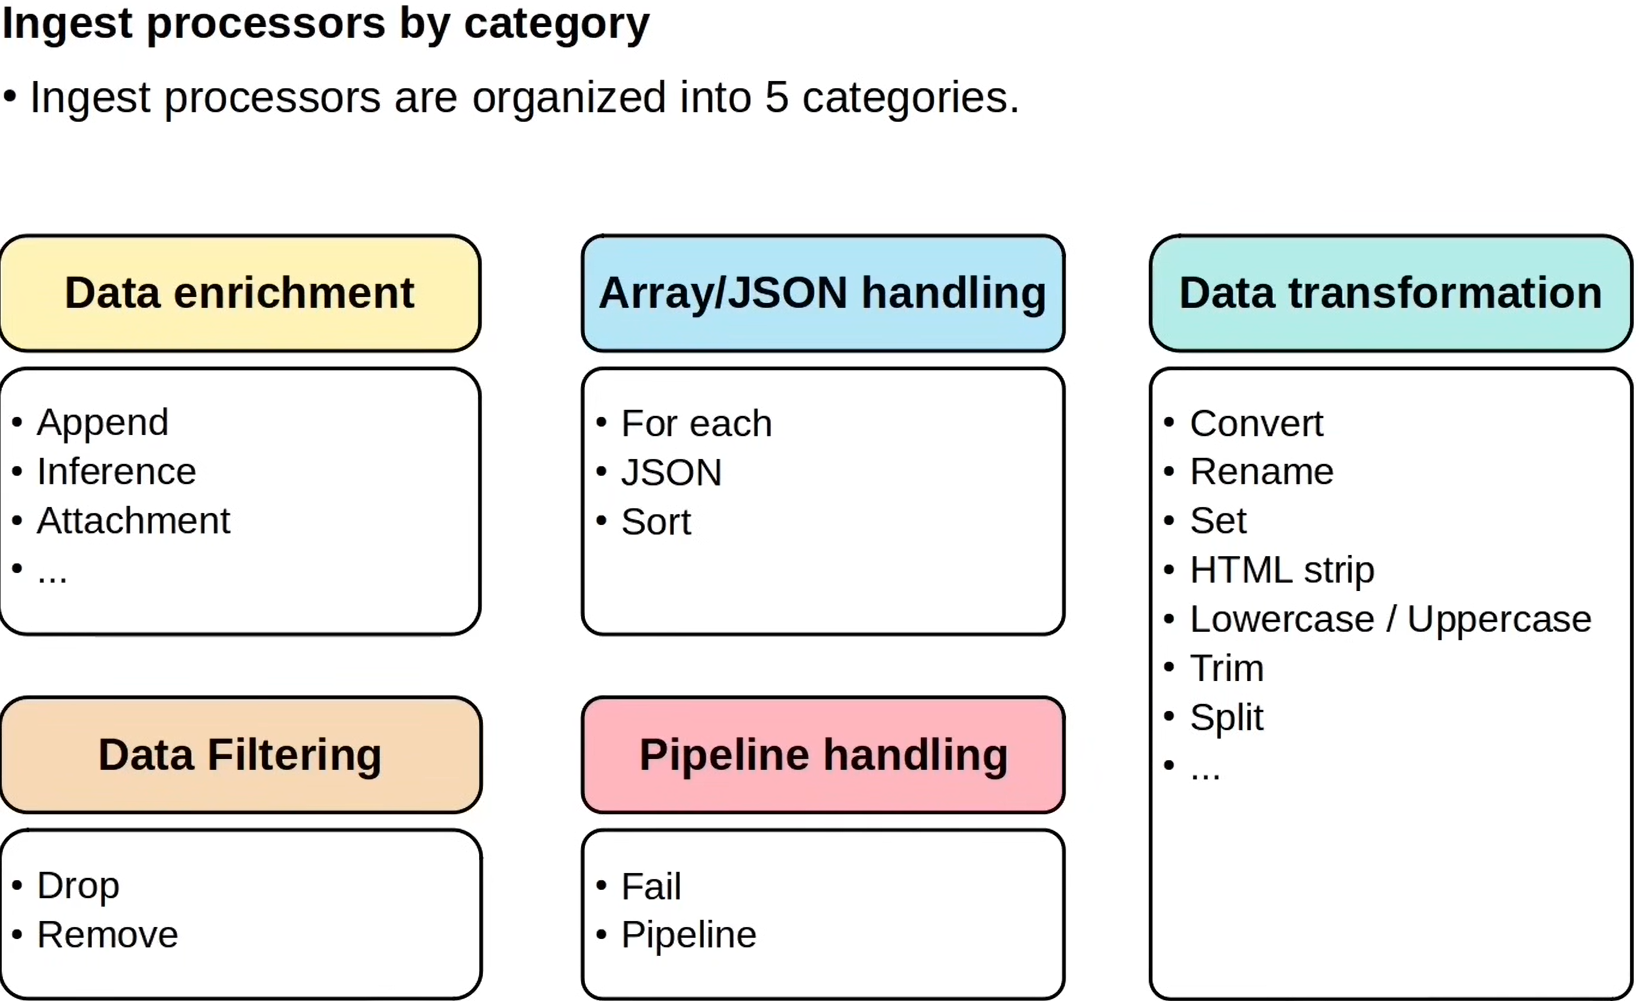

In [ ]:
# creating document
document = {
    "price": "100.50",
    "old_name": "old_value",
    "username": "userNAME",
    "description": "<p>This is a great book about Elasticsearch and HTML.</p>",
    "category": "books",
    "title": "The Great Gatsby     ",
    "tags": "tag1, tag2, tag3",
    "temporary_field": "to be removed"
}


# creating the pipeline
# what the piepline will do: 
# convert price to float, 
# rename old_name to new_name, 
# lowercase username, 
# trim title, 
# split tags into an array + add new_tag to the tag field,
# and remove temporary_field
# add status field with value "active"
# strip HTML tags from description field
pipeline = {
    "description": "Example pipeline with multiple processors",
    "processors": [
        {
            "convert": {
                "field": "price",
                "type": "float",
                "ignore_missing": True
            }
        },
        {
            "rename": {
                "field": "old_name",
                "target_field": "new_name"
            }
        },
        {
            "lowercase": {
                "field": "username"
            }
        },
        {
            "trim": {
                "field": "title"
            }
        },
        {
            "split": {  
                "field": "tags",
                "separator": ", "
            }
        },
        {
            "add": {
                "field": "tags",
                "value": "new_tag"
            }
        },
        {
            "remove": {
                "field": "temporary_field"
            }
        },
        {
            "set": {
                "field": "status",
                "value": "active"
            }
        }
        ,
        {
            "html_strip": {
                "field": "description",
                "ignore_missing": True
            }
        }
        {
            "lowercase": {
                "field": "description"
            }
        }
        {
            "uppercase": {
                "field": "category"
             }  
        }
    ]
}

# create the pipeline in Elasticsearch
response = es.ingest.put_pipeline(id="multi_processor_pipeline", body=pipeline)
pprint(response.body)

